--- ONE-CLASS SVM ---
Încărcare date...
Sampling finalizat: Train=20000, Test=10000
Antrenare One-Class SVM ...
Gata în 8.24 secunde!
Evaluare...

              precision    recall  f1-score   support

      Normal       1.00      0.65      0.79      2556
    Anomalie       0.89      1.00      0.94      7444

    accuracy                           0.91     10000
   macro avg       0.95      0.83      0.87     10000
weighted avg       0.92      0.91      0.90     10000

AUC: 0.8856
Rezultate salvate în: D:\disertatie\rezultate_2018\One_class_SVM


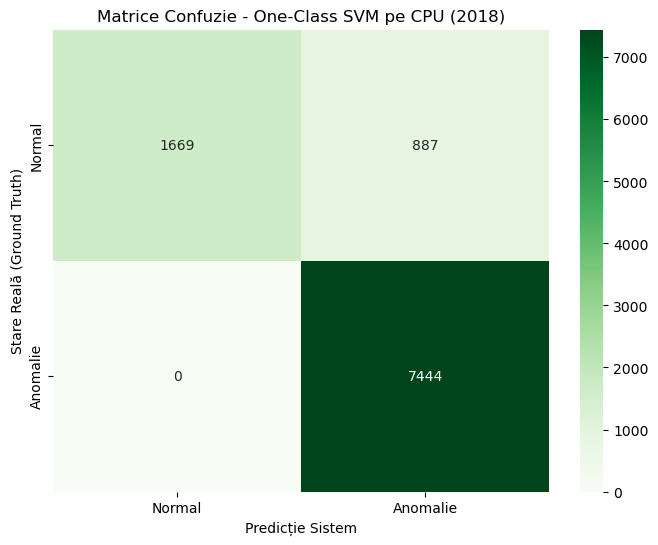

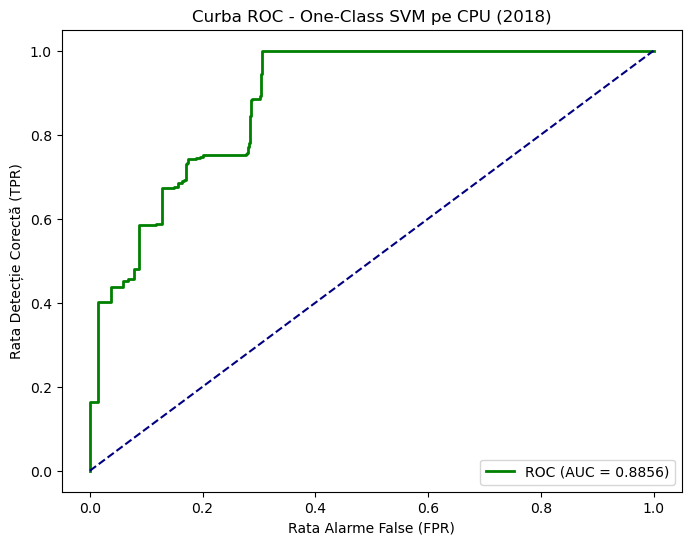

In [2]:
import torch
import numpy as np
import os
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


data_path = r'D:\disertatie\preprocesare_anomalii_2018'
model_save_path = r'D:\disertatie\modele_2018\One_class_SVM'
rezultate_path = r'D:\disertatie\rezultate_2018\One_class_SVM'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("--- ONE-CLASS SVM ---")


print("Încărcare date...")
X_train_full = torch.load(os.path.join(data_path, 'X_train_2018.pt')).numpy()
X_test_full = torch.load(os.path.join(data_path, 'X_test_2018.pt')).numpy()
y_test_full = torch.load(os.path.join(data_path, 'y_test_2018.pt')).numpy()


np.random.seed(42)
n_train = 20000  
n_test = 10000

idx_train = np.random.choice(len(X_train_full), n_train, replace=False)
X_train = X_train_full[idx_train]

idx_test = np.random.choice(len(X_test_full), n_test, replace=False)
X_test = X_test_full[idx_test]
y_test = y_test_full[idx_test]

print(f"Sampling finalizat: Train={n_train}, Test={n_test}")

model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.35, cache_size=8000)

start_time = time.time()
print("Antrenare One-Class SVM ...")
model.fit(X_train)
train_time = time.time() - start_time
print(f"Gata în {train_time:.2f} secunde!")


model_file = os.path.join(model_save_path, 'model_ocsvm_2018_cpu.pkl')
joblib.dump(model, model_file)


print("Evaluare...")
y_pred_raw = model.predict(X_test)
y_pred = [1 if x == -1 else 0 for x in y_pred_raw]

y_scores = -model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Anomalie'])
print("\n" + report)
print(f"AUC: {roc_auc:.4f}")

with open(os.path.join(rezultate_path, 'raport_ocsvm_2018_cpu.txt'), 'w') as f:
    f.write(f"REZULTATE ONE-CLASS SVM\nAUC: {roc_auc:.4f}\nTimp: {train_time:.2f}s\n\n{report}")


plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.title('Matrice Confuzie - One-Class SVM pe CPU (2018)')
plt.savefig(os.path.join(rezultate_path, 'matrice_ocsvm_2018_cpu.png'))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('Rata Alarme False (FPR)')
plt.ylabel('Rata Detecție Corectă (TPR)')
plt.title('Curba ROC - One-Class SVM pe CPU (2018)')
plt.legend(loc="lower right")
plt.savefig(os.path.join(rezultate_path, 'roc_ocsvm_2018_cpu.png'))

print(f"Rezultate salvate în: {rezultate_path}")